# Notebook 1: The Neuron & Backprop Engine

## What We'll Build and Why

In this notebook we build a **complete automatic differentiation engine** from scratch --
no frameworks, no magic, just Python. We will implement a `Value` class that tracks
every arithmetic operation and can compute gradients automatically using the chain rule.
On top of this engine we build neurons, layers, and a full MLP, then train it to
classify 2D data and approximate complex functions.

**Three big ideas** thread through everything we do:

| # | Curriculum Point | Where We See It |
|---|-----------------|-----------------|
| **①** | Universal Approximation Theorem | Section 7 -- wide vs deep networks |
| **②** | ReLU changed everything | Section 4 -- vanishing gradients |
| **⑤** | Backpropagation = chain rule | Sections 2-3 -- the `Value` engine |

**Requirements:** Python 3, NumPy, matplotlib, scikit-learn (for data generation only).


---
## Part 1 -- The `Value` Class: A Scalar Autograd Engine

The core idea: wrap every scalar number in a `Value` object that remembers:
- **what operation** created it (+, *, ReLU, ...)
- **which inputs** (children) fed into that operation
- **how to propagate gradients** backward through that operation

This is *exactly* what PyTorch does with tensors, but we do it for scalars so
every step is transparent.

> **⑤ Curriculum Point -- Backpropagation is just the chain rule.**
> If $z = f(y)$ and $y = g(x)$, then $\frac{dz}{dx} = \frac{dz}{dy} \cdot \frac{dy}{dx}$.
> Our `_backward` lambdas implement exactly this: each operation knows its local derivative
> and multiplies by the incoming gradient.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import math
import random

# Reproducibility
np.random.seed(42)
random.seed(42)

%matplotlib inline
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11


In [2]:
class Value:
    """A scalar value with automatic gradient tracking.

    Stores the numerical value, its gradient (accumulated during backprop),
    a backward function (local chain-rule step), and pointers to children.
    """

    def __init__(self, data, _children=(), _op="", label=""):
        self.data = float(data)
        self.grad = 0.0           # dL/d(self), accumulated during backward()
        self._backward = lambda: None   # local chain-rule step
        self._prev = set(_children)
        self._op = _op
        self.label = label

    # ---- Arithmetic operations ----

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")
        def _backward():
            # d(a+b)/da = 1, d(a+b)/db = 1
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")
        def _backward():
            # d(a*b)/da = b, d(a*b)/db = a
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only int/float powers"
        out = Value(self.data ** other, (self,), f"**{other}")
        def _backward():
            # d(a^n)/da = n * a^(n-1)
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __truediv__(self, other):
        return self * (other ** -1) if isinstance(other, Value) else self * (Value(other) ** -1)

    def __radd__(self, other):
        return self + other

    def __rmul__(self, other):
        return self * other

    def __rsub__(self, other):
        return Value(other) + (-self)

    def __rtruediv__(self, other):
        return Value(other) * (self ** -1)

    # ---- Activation functions ----

    def relu(self):
        out = Value(max(0, self.data), (self,), "relu")
        def _backward():
            # d(relu)/dx = 1 if x > 0 else 0
            self.grad += (1.0 if self.data > 0 else 0.0) * out.grad
        out._backward = _backward
        return out

    def sigmoid(self):
        # Numerically stable sigmoid
        if self.data >= 0:
            s = 1.0 / (1.0 + math.exp(-self.data))
        else:
            e = math.exp(self.data)
            s = e / (1.0 + e)
        out = Value(s, (self,), "sigmoid")
        def _backward():
            # d(sigmoid)/dx = sigmoid * (1 - sigmoid)
            self.grad += s * (1 - s) * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        t = math.tanh(self.data)
        out = Value(t, (self,), "tanh")
        def _backward():
            # d(tanh)/dx = 1 - tanh^2
            self.grad += (1 - t ** 2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        e = math.exp(self.data)
        out = Value(e, (self,), "exp")
        def _backward():
            self.grad += e * out.grad
        out._backward = _backward
        return out

    # ---- Backward pass ----

    def backward(self):
        """Compute gradients for the entire computation graph.

        Uses topological sort to ensure each node is processed
        *after* all nodes that depend on it.
        """
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # Start: dL/dL = 1
        self.grad = 1.0
        # Walk in reverse topological order (output -> inputs)
        for node in reversed(topo):
            node._backward()

    def __repr__(self):
        return f"Value(data={self.data:.4f}, grad={self.grad:.4f})"


### Quick sanity check

Let's create a couple of `Value` objects and verify arithmetic works:


In [3]:
a = Value(3.0, label="a")
b = Value(-2.0, label="b")
c = a + b
d = a * b + b ** 3
print(f"a = {a}")
print(f"b = {b}")
print(f"a + b = {c}")
print(f"a * b + b^3 = {d}")
print(f"  Expected: 3*(-2) + (-2)^3 = -6 + (-8) = -14  -> got {d.data}")


a = Value(data=3.0000, grad=0.0000)
b = Value(data=-2.0000, grad=0.0000)
a + b = Value(data=1.0000, grad=0.0000)
a * b + b^3 = Value(data=-14.0000, grad=0.0000)
  Expected: 3*(-2) + (-2)^3 = -6 + (-8) = -14  -> got -14.0


### Visualizing the computation graph (text-based)

Below is a simple helper that prints the computation graph as an indented tree.
Each node shows its value, its gradient (after `backward()`), and the operation that created it.


In [4]:
def draw_graph(root, indent=0, visited=None):
    """Print a text-based tree of the computation graph."""
    if visited is None:
        visited = set()
    prefix = "  " * indent
    op_str = f" [{root._op}]" if root._op else ""
    lbl = f" ({root.label})" if root.label else ""
    grad_str = f"  grad={root.grad:.4f}" if root.grad != 0 else ""
    print(f"{prefix}Value={root.data:.4f}{lbl}{op_str}{grad_str}")
    if id(root) not in visited:
        visited.add(id(root))
        for child in root._prev:
            draw_graph(child, indent + 1, visited)


# Build a small expression and visualize
x = Value(2.0, label="x")
y = Value(3.0, label="y")
z = x * y + y ** 2
z.backward()

print("Computation graph for z = x*y + y^2:")
print("=" * 50)
draw_graph(z)
print()
print(f"dz/dx = {x.grad:.4f}  (expected: y = 3)")
print(f"dz/dy = {y.grad:.4f}  (expected: x + 2y = 2 + 6 = 8)")


Computation graph for z = x*y + y^2:
Value=15.0000 [+]  grad=1.0000
  Value=9.0000 [**2]  grad=1.0000
    Value=3.0000 (y)  grad=8.0000
  Value=6.0000 [*]  grad=1.0000
    Value=2.0000 (x)  grad=3.0000
    Value=3.0000 (y)  grad=8.0000

dz/dx = 3.0000  (expected: y = 3)
dz/dy = 8.0000  (expected: x + 2y = 2 + 6 = 8)


---
## Part 2 -- Gradient Verification

> **⑤ Curriculum Point: Backpropagation is just the chain rule.**
>
> Let's prove it by hand-computing gradients for a simple expression, then
> checking that our engine gets the same answer.

**Example:** $f = (a + b) \cdot c$ where $a=2, b=3, c=-4$.

By hand:
- Let $d = a + b = 5$
- $f = d \cdot c = -20$
- $\frac{\partial f}{\partial c} = d = 5$
- $\frac{\partial f}{\partial d} = c = -4$
- $\frac{\partial f}{\partial a} = \frac{\partial f}{\partial d} \cdot \frac{\partial d}{\partial a} = -4 \cdot 1 = -4$
- $\frac{\partial f}{\partial b} = \frac{\partial f}{\partial d} \cdot \frac{\partial d}{\partial b} = -4 \cdot 1 = -4$


In [5]:
# Verify with our engine
a = Value(2.0, label="a")
b = Value(3.0, label="b")
c = Value(-4.0, label="c")

d = a + b  # d = 5
f = d * c  # f = -20

f.backward()

print("f = (a + b) * c")
print(f"  f = {f.data:.1f}")
print(f"  df/da = {a.grad:.1f}  (expected: -4)")
print(f"  df/db = {b.grad:.1f}  (expected: -4)")
print(f"  df/dc = {c.grad:.1f}  (expected:  5)")


f = (a + b) * c
  f = -20.0
  df/da = -4.0  (expected: -4)
  df/db = -4.0  (expected: -4)
  df/dc = 5.0  (expected:  5)


### A more complex example: verify gradients through an activation

Let's check: $g = \tanh(2x + 3y)$ at $x=1, y=2$.

By hand:
- $u = 2x + 3y = 8$
- $g = \tanh(8) \approx 0.99999977$
- $\frac{\partial g}{\partial u} = 1 - \tanh^2(8) \approx 4.5 \times 10^{-7}$
- $\frac{\partial g}{\partial x} = \frac{\partial g}{\partial u} \cdot 2 \approx 9.1 \times 10^{-7}$
- $\frac{\partial g}{\partial y} = \frac{\partial g}{\partial u} \cdot 3 \approx 1.4 \times 10^{-6}$

These tiny gradients are the **vanishing gradient problem** in action!


In [6]:
x = Value(1.0, label="x")
y = Value(2.0, label="y")
g = (Value(2.0) * x + Value(3.0) * y).tanh()
g.backward()

print("g = tanh(2x + 3y) at x=1, y=2")
print(f"  g = {g.data:.8f}")
print(f"  dg/dx = {x.grad:.2e}  (expected: ~9.1e-7)")
print(f"  dg/dy = {y.grad:.2e}  (expected: ~1.4e-6)")
print()
print("The gradients are tiny because tanh saturates near +/-1.")
print("This is the vanishing gradient problem we explore next.")


g = tanh(2x + 3y) at x=1, y=2
  g = 0.99999977
  dg/dx = 9.00e-07  (expected: ~9.1e-7)
  dg/dy = 1.35e-06  (expected: ~1.4e-6)

The gradients are tiny because tanh saturates near +/-1.
This is the vanishing gradient problem we explore next.


### Numerical gradient check

We can also verify our analytical gradients by comparing with **finite differences**:
$\frac{\partial f}{\partial x} \approx \frac{f(x + h) - f(x - h)}{2h}$

This is slow but serves as a ground truth.


In [7]:
def numerical_gradient(func, inputs, idx, h=1e-5):
    """Compute df/d(inputs[idx]) using central finite differences."""
    # Forward: f(x + h)
    inputs[idx].data += h
    f_plus = func().data
    # Backward: f(x - h)
    inputs[idx].data -= 2 * h
    f_minus = func().data
    # Restore
    inputs[idx].data += h
    return (f_plus - f_minus) / (2 * h)


# Test: f = (a * b + c) ** 2
a = Value(1.5)
b = Value(2.0)
c = Value(-1.0)

def test_fn():
    return (a * b + c) ** 2

result = test_fn()
result.backward()

# Compare analytical vs numerical
for name, val in [("a", a), ("b", b), ("c", c)]:
    num_grad = numerical_gradient(test_fn, [a, b, c], [a, b, c].index(val))
    print(f"d/d{name}: analytical={val.grad:.6f}  numerical={num_grad:.6f}  match={abs(val.grad - num_grad) < 1e-4}")


d/da: analytical=8.000000  numerical=8.000000  match=True
d/db: analytical=6.000000  numerical=6.000000  match=True
d/dc: analytical=4.000000  numerical=4.000000  match=True


---
## Part 3 -- Sigmoid vs ReLU: The Vanishing Gradient Problem

> **② Curriculum Point: ReLU changed everything.**
>
> Before ~2011, most neural networks used sigmoid or tanh activations.
> These functions **squash** their inputs into a bounded range, which means
> their derivatives are always less than 1. When you multiply many such
> derivatives together (the chain rule through many layers), the gradient
> **vanishes exponentially**.
>
> ReLU ($\max(0, x)$) has gradient exactly **0 or 1**. No squashing, no vanishing.
> This simple change unlocked deep networks.


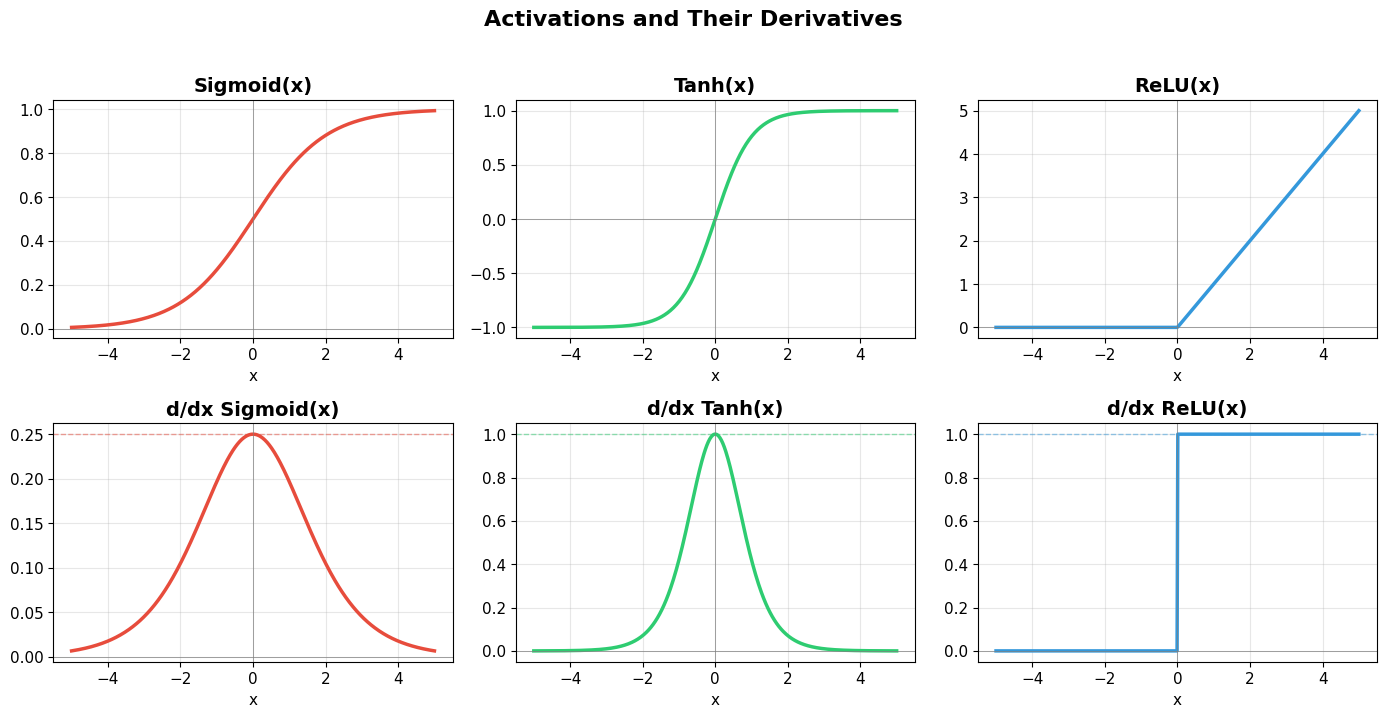

KEY OBSERVATION:
  Sigmoid max derivative: 0.2500  (always < 0.25)
  Tanh max derivative:    0.9999  (always < 1.0)
  ReLU derivative:        0 or 1 -- no squashing!


In [8]:
# ---- Plot sigmoid, tanh, ReLU and their derivatives ----
xs = np.linspace(-5, 5, 500)

# Compute activations
sigmoid_y = 1 / (1 + np.exp(-xs))
tanh_y = np.tanh(xs)
relu_y = np.maximum(0, xs)

# Compute derivatives
sigmoid_dy = sigmoid_y * (1 - sigmoid_y)
tanh_dy = 1 - tanh_y ** 2
relu_dy = (xs > 0).astype(float)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

# Top row: activations
for ax, y, name, color in zip(axes[0],
                               [sigmoid_y, tanh_y, relu_y],
                               ["Sigmoid", "Tanh", "ReLU"],
                               ["#e74c3c", "#2ecc71", "#3498db"]):
    ax.plot(xs, y, color=color, linewidth=2.5)
    ax.set_title(f"{name}(x)", fontsize=14, fontweight="bold")
    ax.axhline(y=0, color="gray", linewidth=0.5)
    ax.axvline(x=0, color="gray", linewidth=0.5)
    ax.set_xlabel("x")
    ax.grid(True, alpha=0.3)

# Bottom row: derivatives
for ax, dy, name, color in zip(axes[1],
                                [sigmoid_dy, tanh_dy, relu_dy],
                                ["Sigmoid", "Tanh", "ReLU"],
                                ["#e74c3c", "#2ecc71", "#3498db"]):
    ax.plot(xs, dy, color=color, linewidth=2.5)
    ax.set_title(f"d/dx {name}(x)", fontsize=14, fontweight="bold")
    ax.axhline(y=0, color="gray", linewidth=0.5)
    ax.axvline(x=0, color="gray", linewidth=0.5)
    ax.set_xlabel("x")
    ax.grid(True, alpha=0.3)
    # Highlight max derivative
    ax.axhline(y=max(dy), color=color, linewidth=1, linestyle="--", alpha=0.5)

fig.suptitle("Activations and Their Derivatives", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("KEY OBSERVATION:")
print(f"  Sigmoid max derivative: {max(sigmoid_dy):.4f}  (always < 0.25)")
print(f"  Tanh max derivative:    {max(tanh_dy):.4f}  (always < 1.0)")
print(f"  ReLU derivative:        0 or 1 -- no squashing!")


### The vanishing gradient problem -- numerically

Let's simulate what happens when a gradient passes through $n$ layers.
In the best case, each layer multiplies the gradient by the **maximum** derivative
of the activation function.


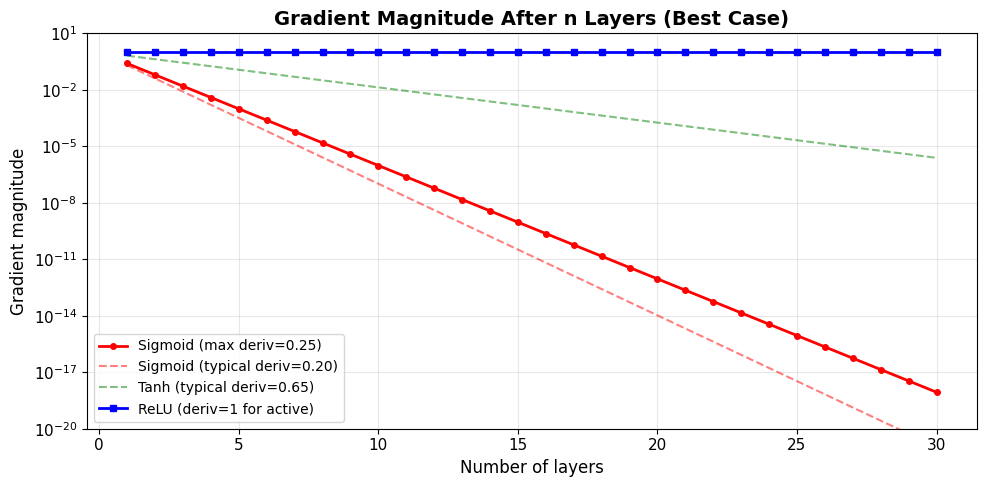

After 10 sigmoid layers, gradient shrinks to: 9.54e-07
After 20 sigmoid layers, gradient shrinks to: 9.09e-13
After 10 ReLU layers, gradient remains:       1.0


In [9]:
# Simulate gradient magnitude after passing through n layers
# We assume "best case" -- gradient at the maximum of each activation's derivative
layers = np.arange(1, 31)
sigmoid_grad = 0.25 ** layers    # max sigmoid derivative = 0.25
tanh_grad = 1.0 ** layers        # max tanh derivative = 1.0 (but rarely achieved)
relu_grad = 1.0 ** layers        # ReLU derivative = 1 for active neurons

# More realistic: average gradient magnitudes
sigmoid_avg_grad = 0.20 ** layers  # typical sigmoid derivative
tanh_avg_grad = 0.65 ** layers     # typical tanh derivative

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(layers, sigmoid_grad, "r-o", markersize=4, label="Sigmoid (max deriv=0.25)", linewidth=2)
ax.semilogy(layers, sigmoid_avg_grad, "r--", alpha=0.5, label="Sigmoid (typical deriv=0.20)")
ax.semilogy(layers, tanh_avg_grad, "g--", alpha=0.5, label="Tanh (typical deriv=0.65)")
ax.semilogy(layers, relu_grad, "b-s", markersize=4, label="ReLU (deriv=1 for active)", linewidth=2)
ax.set_xlabel("Number of layers", fontsize=12)
ax.set_ylabel("Gradient magnitude", fontsize=12)
ax.set_title("Gradient Magnitude After n Layers (Best Case)", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(1e-20, 10)
plt.tight_layout()
plt.show()

print(f"After 10 sigmoid layers, gradient shrinks to: {0.25**10:.2e}")
print(f"After 20 sigmoid layers, gradient shrinks to: {0.25**20:.2e}")
print(f"After 10 ReLU layers, gradient remains:       {1.0**10:.1f}")


### Verify with our autograd engine

Let's stack activations and watch the gradient flow through our actual `Value` engine:


In [10]:
# Stack 10 sigmoid activations: y = sigmoid(sigmoid(...sigmoid(x)...))
x_sig = Value(0.5, label="x")
y_sig = x_sig
for i in range(10):
    y_sig = y_sig.sigmoid()
y_sig.backward()

# Stack 10 ReLU activations: y = relu(relu(...relu(x)...))
x_relu = Value(0.5, label="x")
y_relu = x_relu
for i in range(10):
    y_relu = y_relu.relu()
y_relu.backward()

print("Gradient at input after 10 stacked activations:")
print(f"  10x Sigmoid: dy/dx = {x_sig.grad:.2e}")
print(f"  10x ReLU:    dy/dx = {x_relu.grad:.2e}")
print()
print("ReLU preserves the gradient perfectly (when active).")
print("Sigmoid crushes it to near-zero -- this is why deep sigmoid networks")
print("were nearly impossible to train before ReLU became standard (~2011).")


Gradient at input after 10 stacked activations:
  10x Sigmoid: dy/dx = 3.48e-07
  10x ReLU:    dy/dx = 1.00e+00

ReLU preserves the gradient perfectly (when active).
Sigmoid crushes it to near-zero -- this is why deep sigmoid networks
were nearly impossible to train before ReLU became standard (~2011).


---
## Part 4 -- Building a Neural Network from `Value` Objects

Now we turn our autograd engine into a full neural network library.
We build three classes, each wrapping the one below:

```
MLP  (Multi-Layer Perceptron)
 -> Layer  (a list of neurons)
     -> Neuron  (weighted sum + bias + activation)
         -> Value  (our autograd scalar)
```


In [11]:
class Neuron:
    """A single neuron: weighted sum + bias + activation."""

    def __init__(self, n_in, activation="relu"):
        # Initialize weights from uniform[-1, 1] -- small random values
        self.w = [Value(random.uniform(-1, 1), label=f"w{i}") for i in range(n_in)]
        self.b = Value(0.0, label="b")
        self.activation = activation

    def __call__(self, x):
        # Weighted sum: w0*x0 + w1*x1 + ... + b
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        # Apply activation
        if self.activation == "relu":
            return act.relu()
        elif self.activation == "sigmoid":
            return act.sigmoid()
        elif self.activation == "tanh":
            return act.tanh()
        elif self.activation == "linear":
            return act
        else:
            raise ValueError(f"Unknown activation: {self.activation}")

    def parameters(self):
        return self.w + [self.b]


class Layer:
    """A layer of neurons."""

    def __init__(self, n_in, n_out, activation="relu"):
        self.neurons = [Neuron(n_in, activation) for _ in range(n_out)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]


class MLP:
    """Multi-layer perceptron."""

    def __init__(self, n_in, layer_sizes, activations=None):
        sizes = [n_in] + layer_sizes
        if activations is None:
            # ReLU for hidden layers, linear for output
            activations = ["relu"] * (len(layer_sizes) - 1) + ["linear"]
        self.layers = [Layer(sizes[i], sizes[i + 1], activations[i])
                       for i in range(len(layer_sizes))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0.0


# Quick test
random.seed(42)
net = MLP(2, [4, 4, 1])
x_test = [Value(1.0), Value(2.0)]
y_test = net(x_test)
print(f"Test forward pass: input=[1.0, 2.0] -> output={y_test.data:.4f}")
print(f"Total parameters: {len(net.parameters())}")


Test forward pass: input=[1.0, 2.0] -> output=-0.7102
Total parameters: 37


---
## Part 5 -- Training on the Moons Dataset

We'll use scikit-learn's `make_moons` to generate a non-linearly-separable 2D dataset,
then train our MLP to classify it. This demonstrates the full training loop:
1. Forward pass (compute predictions)
2. Loss computation (hinge loss + L2 regularization)
3. Backward pass (compute all gradients)
4. Parameter update (gradient descent)

**Note:** Our scalar autograd is intentionally slow -- this is pedagogical code.
We use a small dataset (50 points) and small network (8 -> 8 -> 1) to keep runtime under 30s.


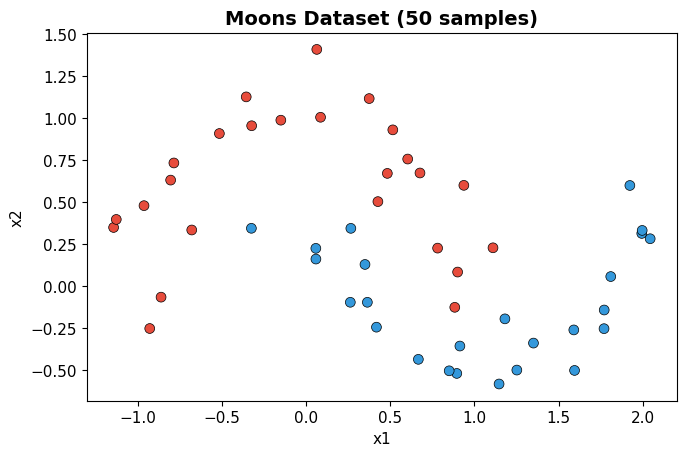

In [12]:
from sklearn.datasets import make_moons

# Generate data -- deliberately small for our scalar engine
X, y = make_moons(n_samples=50, noise=0.15, random_state=42)
# Convert labels from {0, 1} to {-1, +1} for hinge loss
y = 2 * y - 1

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#e74c3c" if yi == -1 else "#3498db" for yi in y]
ax.scatter(X[:, 0], X[:, 1], c=colors, s=50, edgecolors="k", linewidth=0.5)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Moons Dataset (50 samples)", fontsize=14, fontweight="bold")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


### Training loop

We'll use a simple **hinge loss** (like an SVM) plus L2 regularization:

$$\mathcal{L} = \frac{1}{N} \sum_i \max(0, 1 - y_i \hat{y}_i) + \lambda \sum_j w_j^2$$

Each epoch:
1. Forward pass for all samples
2. Compute loss
3. Zero gradients, then backward
4. Update parameters with gradient descent


In [13]:
# Train the network on moons data
random.seed(42)
np.random.seed(42)

# Build network: 2 inputs -> 8 -> 8 -> 1 output
model = MLP(2, [8, 8, 1])
print(f"Parameters: {len(model.parameters())}")

# Hyperparameters
learning_rate = 0.1
reg_lambda = 1e-4
epochs = 30          # Keep low -- scalar autograd is slow by design

# Storage for decision boundary snapshots
snapshots = {}
loss_history = []

for epoch in range(epochs):
    # Forward pass -- compute predictions for all samples
    predictions = [model([Value(x[0]), Value(x[1])]) for x in X]

    # Hinge loss: max(0, 1 - y * yhat)
    losses = [(1 + Value(-yi) * pred).relu() for yi, pred in zip(y, predictions)]
    data_loss = sum(losses, Value(0.0)) * (1.0 / len(losses))

    # L2 regularization
    reg_loss = sum((p * p for p in model.parameters()), Value(0.0)) * reg_lambda
    total_loss = data_loss + reg_loss

    # Backward pass
    model.zero_grad()
    total_loss.backward()

    # Gradient descent update
    for p in model.parameters():
        p.data -= learning_rate * p.grad

    # Accuracy
    accuracy = sum(1 for pred, yi in zip(predictions, y)
                   if (pred.data > 0) == (yi > 0)) / len(y)

    loss_history.append(total_loss.data)

    # Save snapshots for visualization
    if epoch in [0, 4, 9, 19, 29]:
        # Save parameter values at this epoch
        snapshots[epoch] = [p.data for p in model.parameters()]

    if epoch % 5 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch:3d}  |  Loss: {total_loss.data:.4f}  |  Accuracy: {accuracy:.0%}")

print("\nTraining complete!")


Parameters: 105
Epoch   0  |  Loss: 0.9290  |  Accuracy: 66%


Epoch   5  |  Loss: 0.8802  |  Accuracy: 68%


Epoch  10  |  Loss: 0.8281  |  Accuracy: 68%


Epoch  15  |  Loss: 0.7725  |  Accuracy: 72%


Epoch  20  |  Loss: 0.6764  |  Accuracy: 72%


Epoch  25  |  Loss: 0.5216  |  Accuracy: 74%


Epoch  29  |  Loss: 0.4662  |  Accuracy: 78%

Training complete!


### Loss curve

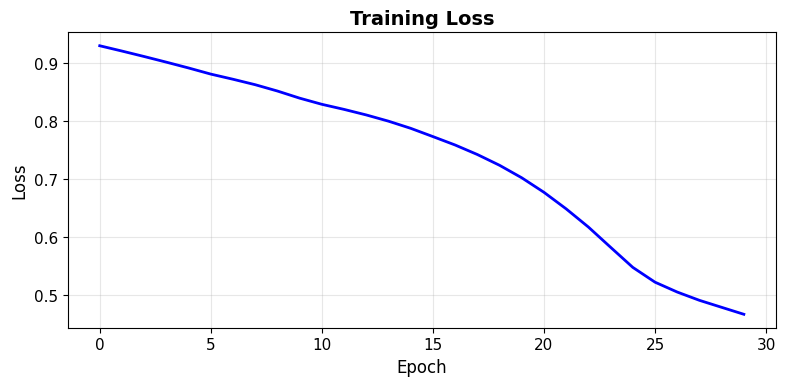

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(loss_history, "b-", linewidth=2)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("Training Loss", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Decision boundary evolution

Let's see how the model's decision boundary changes during training.
We need to rebuild the model at each saved snapshot to visualize it.


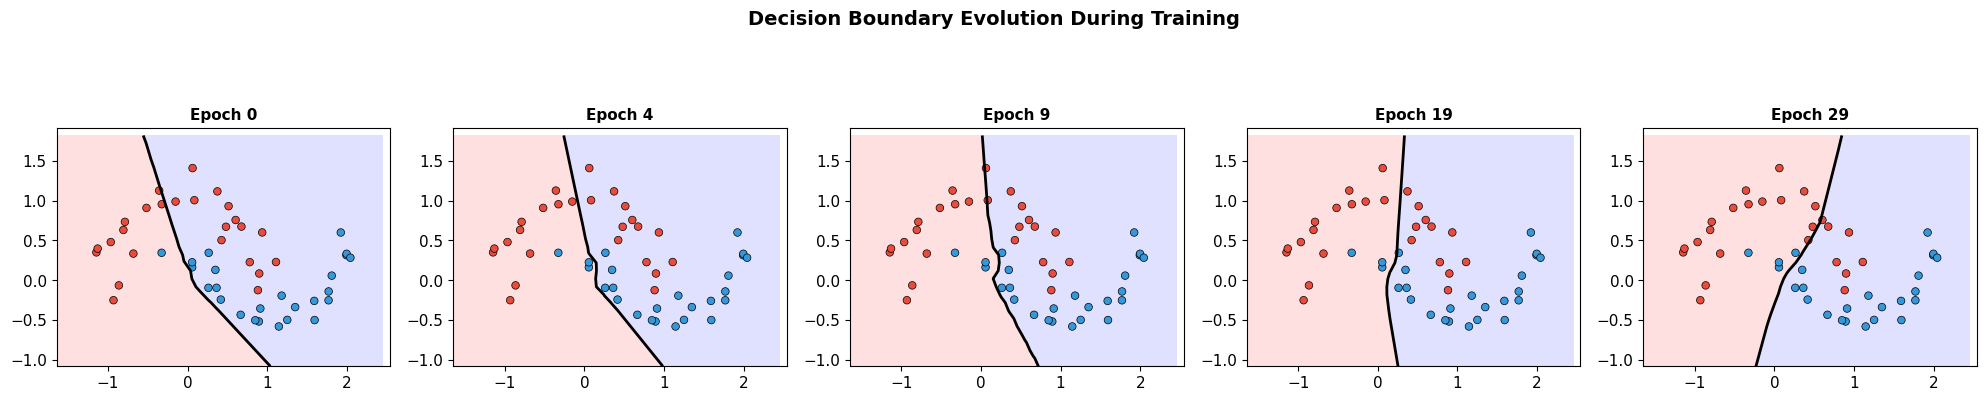

In [15]:
def plot_decision_boundary(model, X, y, ax, title=""):
    """Plot the decision boundary of a binary classifier."""
    h = 0.1  # Grid resolution
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid_points = np.c_[xx.ravel(), yy.ravel()]

    # Predict on grid
    Z = []
    for pt in grid_points:
        pred = model([Value(pt[0]), Value(pt[1])])
        Z.append(pred.data)
    Z = np.array(Z).reshape(xx.shape)

    # Plot
    ax.contourf(xx, yy, Z, levels=[-1e9, 0, 1e9], colors=["#ffcccc", "#ccccff"], alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0], colors=["k"], linewidths=2)
    colors = ["#e74c3c" if yi == -1 else "#3498db" for yi in y]
    ax.scatter(X[:, 0], X[:, 1], c=colors, s=30, edgecolors="k", linewidth=0.5)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect("equal")


# Rebuild model at each snapshot and plot
snapshot_epochs = sorted(snapshots.keys())
fig, axes = plt.subplots(1, len(snapshot_epochs), figsize=(4 * len(snapshot_epochs), 4))
if len(snapshot_epochs) == 1:
    axes = [axes]

for ax, ep in zip(axes, snapshot_epochs):
    # Rebuild model with saved parameters
    random.seed(42)
    snap_model = MLP(2, [8, 8, 1])
    for p, saved_val in zip(snap_model.parameters(), snapshots[ep]):
        p.data = saved_val
    plot_decision_boundary(snap_model, X, y, ax, title=f"Epoch {ep}")

fig.suptitle("Decision Boundary Evolution During Training", fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()


---
## Part 6 -- Universal Approximation Theorem

> **① Curriculum Point: Universal Approximation Theorem.**
>
> **Theorem (informal):** A neural network with a single hidden layer and enough neurons
> can approximate *any* continuous function on a bounded domain to arbitrary accuracy.
>
> **But:** "enough neurons" might mean an astronomical number. In practice,
> **deeper networks** achieve the same quality with far fewer total parameters.
> Depth buys you **compositionality** -- each layer learns features on top of the previous layer's features.

### Target function

We'll try to learn: $f(x) = \sin(2x) + 0.5 \cos(5x)$ on $[-\pi, \pi]$.
This is a complex, non-trivial function that requires significant capacity.


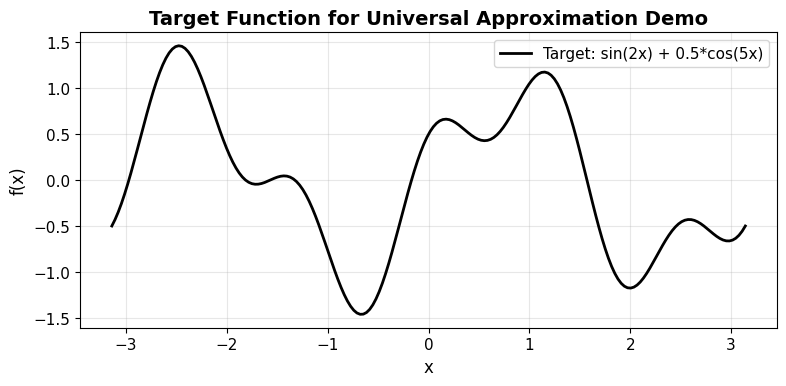

In [16]:
# Target function
def target_fn(x):
    return math.sin(2 * x) + 0.5 * math.cos(5 * x)

# Plot the target
xs_plot = np.linspace(-math.pi, math.pi, 200)
ys_plot = [target_fn(x) for x in xs_plot]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(xs_plot, ys_plot, "k-", linewidth=2, label="Target: sin(2x) + 0.5*cos(5x)")
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("f(x)", fontsize=12)
ax.set_title("Target Function for Universal Approximation Demo", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Training helper

We'll write a reusable training function so we can compare architectures fairly.

**Note:** We use only 20 training points and keep epochs low for speed.
Even with these constraints, the difference between wide/shallow and deep/narrow
architectures is clearly visible.


In [17]:
def train_1d_model(model, x_train, y_train, epochs=200, lr=0.01):
    """Train a 1D regression model using MSE loss."""
    loss_history = []
    for epoch in range(epochs):
        # Forward pass
        predictions = [model([Value(x)]) for x in x_train]
        targets = [Value(yt) for yt in y_train]

        # MSE loss
        losses = [(pred - tgt) ** 2 for pred, tgt in zip(predictions, targets)]
        loss = sum(losses, Value(0.0)) * (1.0 / len(losses))

        # Backward
        model.zero_grad()
        loss.backward()

        # Update
        for p in model.parameters():
            p.data -= lr * p.grad

        loss_history.append(loss.data)

        if epoch % 50 == 0:
            print(f"  Epoch {epoch:3d}  Loss: {loss.data:.6f}")

    return loss_history


def predict_1d(model, xs):
    """Predict for an array of x values."""
    return [model([Value(x)]).data for x in xs]


### Experiment 1: Wide shallow network (1 hidden layer, 32 neurons)

In [18]:
# Generate training data (20 points)
random.seed(42)
np.random.seed(42)
x_train = np.linspace(-math.pi, math.pi, 20)
y_train = [target_fn(x) for x in x_train]

# Wide shallow: 1 -> 32 -> 1
print("Training WIDE SHALLOW network (1 -> 32 -> 1)...")
random.seed(42)
wide_model = MLP(1, [32, 1], activations=["relu", "linear"])
print(f"  Parameters: {len(wide_model.parameters())}")
wide_loss = train_1d_model(wide_model, x_train, y_train, epochs=200, lr=0.005)


Training WIDE SHALLOW network (1 -> 32 -> 1)...
  Parameters: 97


  Epoch   0  Loss: 10.755298


  Epoch  50  Loss: 0.556638


  Epoch 100  Loss: 0.477699


  Epoch 150  Loss: 0.429315


### Experiment 2: Deep narrow network (3 hidden layers, 8 neurons each)

In [19]:
# Deep narrow: 1 -> 8 -> 8 -> 8 -> 1
print("Training DEEP NARROW network (1 -> 8 -> 8 -> 8 -> 1)...")
random.seed(42)
deep_model = MLP(1, [8, 8, 8, 1], activations=["relu", "relu", "relu", "linear"])
print(f"  Parameters: {len(deep_model.parameters())}")
deep_loss = train_1d_model(deep_model, x_train, y_train, epochs=200, lr=0.005)


Training DEEP NARROW network (1 -> 8 -> 8 -> 8 -> 1)...
  Parameters: 169


  Epoch   0  Loss: 1.434629


  Epoch  50  Loss: 0.519712


  Epoch 100  Loss: 0.502747


  Epoch 150  Loss: 0.486791


### Comparison

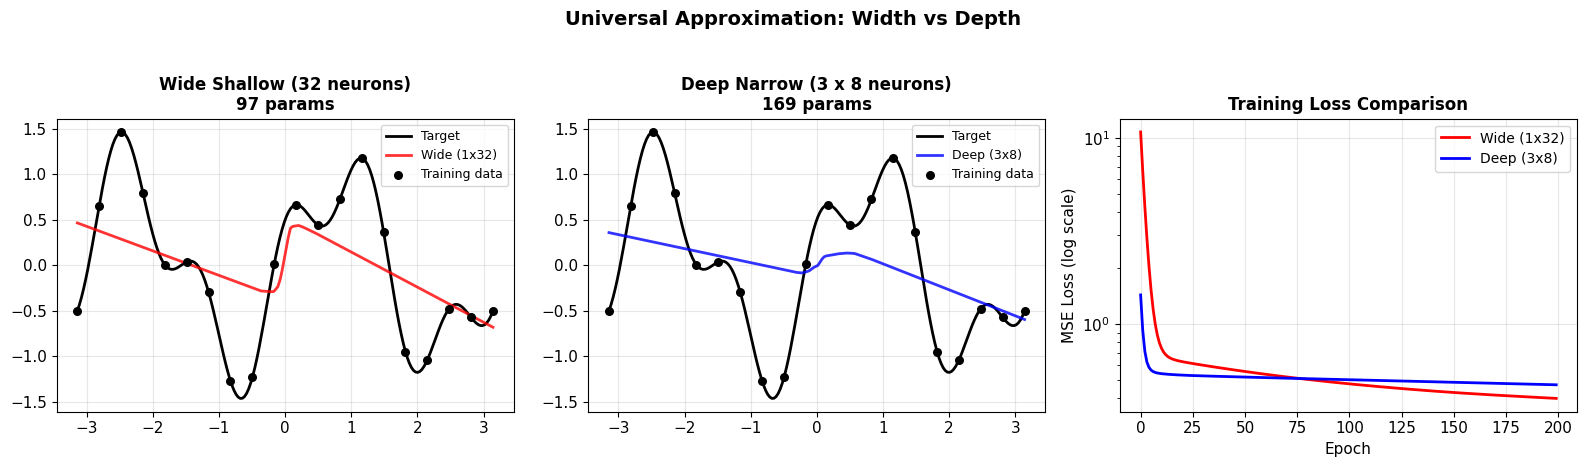

KEY INSIGHT:
  Wide model (32 neurons, 1 layer):  97 parameters
  Deep model (8 neurons, 3 layers):  169 parameters
  Both can approximate the target, but depth enables composition of features.
  Deeper networks learn hierarchical representations -- each layer builds on the last.


In [20]:
wide_preds = predict_1d(wide_model, xs_plot)
deep_preds = predict_1d(deep_model, xs_plot)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Left: wide model fit
axes[0].plot(xs_plot, ys_plot, "k-", linewidth=2, label="Target")
axes[0].plot(xs_plot, wide_preds, "r-", linewidth=2, alpha=0.8, label="Wide (1x32)")
axes[0].scatter(x_train, y_train, c="black", s=30, zorder=5, label="Training data")
axes[0].set_title(f"Wide Shallow (32 neurons)\n{len(wide_model.parameters())} params", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Middle: deep model fit
axes[1].plot(xs_plot, ys_plot, "k-", linewidth=2, label="Target")
axes[1].plot(xs_plot, deep_preds, "b-", linewidth=2, alpha=0.8, label="Deep (3x8)")
axes[1].scatter(x_train, y_train, c="black", s=30, zorder=5, label="Training data")
axes[1].set_title(f"Deep Narrow (3 x 8 neurons)\n{len(deep_model.parameters())} params", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Right: loss comparison
axes[2].semilogy(wide_loss, "r-", linewidth=2, label="Wide (1x32)")
axes[2].semilogy(deep_loss, "b-", linewidth=2, label="Deep (3x8)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("MSE Loss (log scale)")
axes[2].set_title("Training Loss Comparison", fontsize=12, fontweight="bold")
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

fig.suptitle("Universal Approximation: Width vs Depth", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

print("KEY INSIGHT:")
print(f"  Wide model (32 neurons, 1 layer):  {len(wide_model.parameters())} parameters")
print(f"  Deep model (8 neurons, 3 layers):  {len(deep_model.parameters())} parameters")
print("  Both can approximate the target, but depth enables composition of features.")
print("  Deeper networks learn hierarchical representations -- each layer builds on the last.")


> **① Universal Approximation in Practice**
>
> The theorem guarantees that a wide-enough single layer *can* fit any function,
> but it says nothing about how *efficiently*. In practice:
> - **Wide + shallow** needs many neurons and may not generalize well
> - **Deep + narrow** learns compositional features and often generalizes better
> - This is why modern networks are deep, not just wide
>
> In Notebook 2 we'll see this play out with real image data (MNIST).


---
## Part 7 -- Exercises

Work through these exercises to solidify your understanding.
Each exercise has a solution below -- but try it yourself first!


### Exercise 1: Hand-Compute and Verify Gradients

**Task:** For the expression $f = (a \cdot b + c)^2$ where $a=3, b=-2, c=5$:

1. Compute $f$ by hand
2. Compute $\frac{\partial f}{\partial a}$, $\frac{\partial f}{\partial b}$, $\frac{\partial f}{\partial c}$ by hand
3. Verify with our `Value` engine

**Hints:**
- $f = (3 \cdot (-2) + 5)^2 = (-6 + 5)^2 = 1$
- Use the chain rule: $\frac{\partial f}{\partial a} = 2(ab+c) \cdot b$


In [21]:
# ===== EXERCISE 1 -- Try it yourself first! =====
#
# Hand computation:
#   f = (a*b + c)^2 = (3*(-2) + 5)^2 = (-1)^2 = 1
#   Let u = a*b + c = -1
#   df/du = 2*u = -2
#   du/da = b = -2  ->  df/da = df/du * du/da = (-2)*(-2) = 4
#   du/db = a = 3   ->  df/db = df/du * du/db = (-2)*(3) = -6
#   du/dc = 1       ->  df/dc = df/du * du/dc = (-2)*(1) = -2

# --- Solution ---

a = Value(3.0, label="a")
b = Value(-2.0, label="b")
c = Value(5.0, label="c")

f = (a * b + c) ** 2
f.backward()

print("f = (a * b + c)^2  where a=3, b=-2, c=5")
print(f"  f    = {f.data:.1f}  (expected: 1)")
print(f"  df/da = {a.grad:.1f}  (expected: 4)")
print(f"  df/db = {b.grad:.1f}  (expected: -6)")
print(f"  df/dc = {c.grad:.1f}  (expected: -2)")


f = (a * b + c)^2  where a=3, b=-2, c=5
  f    = 1.0  (expected: 1)
  df/da = 4.0  (expected: 4)
  df/db = -6.0  (expected: -6)
  df/dc = -2.0  (expected: -2)


---
### Exercise 2: Implement and Test Leaky ReLU

**Task:** Add a `leaky_relu(alpha=0.01)` method to the `Value` class and verify it works.

Leaky ReLU: $f(x) = x$ if $x > 0$, else $\alpha \cdot x$

Its derivative: $f'(x) = 1$ if $x > 0$, else $\alpha$

This fixes the "dead neuron" problem of standard ReLU (where neurons with negative
inputs have zero gradient and can never recover).


leaky_relu(3.0) = 3.0000  (expected: 3.0)
  gradient = 1.0000  (expected: 1.0)
leaky_relu(-2.0, alpha=0.1) = -0.2000  (expected: -0.2)
  gradient = 0.1000  (expected: 0.1)


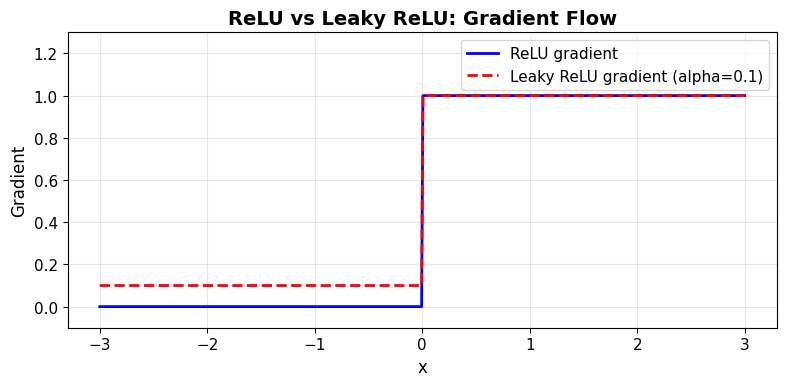


Leaky ReLU lets gradients flow even for negative inputs.
This prevents dead neurons that can never recover.


In [22]:
# ===== EXERCISE 2 -- Try it yourself first! =====
# --- Solution ---

def leaky_relu(self, alpha=0.01):
    """Leaky ReLU: max(alpha*x, x)"""
    out_val = self.data if self.data > 0 else alpha * self.data
    out = Value(out_val, (self,), "leaky_relu")
    def _backward():
        self.grad += (1.0 if self.data > 0 else alpha) * out.grad
    out._backward = _backward
    return out

# Monkey-patch it onto Value
Value.leaky_relu = leaky_relu

# Test with positive input
x = Value(3.0)
y = x.leaky_relu()
y.backward()
print(f"leaky_relu(3.0) = {y.data:.4f}  (expected: 3.0)")
print(f"  gradient = {x.grad:.4f}  (expected: 1.0)")

# Test with negative input
x = Value(-2.0)
y = x.leaky_relu(alpha=0.1)
y.backward()
print(f"leaky_relu(-2.0, alpha=0.1) = {y.data:.4f}  (expected: -0.2)")
print(f"  gradient = {x.grad:.4f}  (expected: 0.1)")

# Compare gradients: plot relu vs leaky_relu derivatives
xs = np.linspace(-3, 3, 500)
relu_grads = [1.0 if x > 0 else 0.0 for x in xs]
leaky_grads = [1.0 if x > 0 else 0.1 for x in xs]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(xs, relu_grads, "b-", linewidth=2, label="ReLU gradient")
ax.plot(xs, leaky_grads, "r--", linewidth=2, label="Leaky ReLU gradient (alpha=0.1)")
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("Gradient", fontsize=12)
ax.set_title("ReLU vs Leaky ReLU: Gradient Flow", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.1, 1.3)
plt.tight_layout()
plt.show()

print("\nLeaky ReLU lets gradients flow even for negative inputs.")
print("This prevents dead neurons that can never recover.")


---
### Exercise 3: Compare Training with Sigmoid vs ReLU Activations

**Task:** Train two identical networks on the moons dataset --
one using sigmoid activations and one using ReLU activations.
Compare their loss curves and final accuracy.


=== ReLU Network ===


  Epoch  0: loss=0.9290  acc=66%


  Epoch  5: loss=0.8802  acc=68%


  Epoch 10: loss=0.8281  acc=68%


  Epoch 15: loss=0.7725  acc=72%


  Epoch 19: loss=0.7015  acc=72%

=== Sigmoid Network ===
  Epoch  0: loss=0.9853  acc=52%


  Epoch  5: loss=0.9402  acc=60%


  Epoch 10: loss=0.8814  acc=72%


  Epoch 15: loss=0.7965  acc=78%


  Epoch 19: loss=0.6999  acc=76%


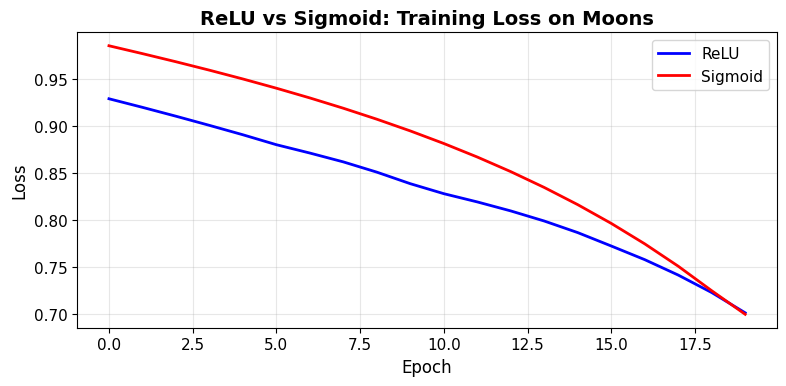


ReLU typically converges faster and more reliably than sigmoid,
especially in deeper networks where sigmoid suffers from vanishing gradients.


In [23]:
# ===== EXERCISE 3 -- Try it yourself first! =====
# --- Solution ---

from sklearn.datasets import make_moons

X_ex, y_ex = make_moons(n_samples=50, noise=0.15, random_state=42)
y_ex = 2 * y_ex - 1  # Convert to {-1, +1}

def train_classifier(model, X, y, epochs=20, lr=0.1):
    """Train a binary classifier and return loss history."""
    losses_hist = []
    for epoch in range(epochs):
        preds = [model([Value(x[0]), Value(x[1])]) for x in X]
        data_loss = sum((1 + Value(-yi) * pred).relu()
                        for yi, pred in zip(y, preds))
        data_loss = data_loss * (1.0 / len(y))
        reg = sum((p * p for p in model.parameters()), Value(0.0)) * 1e-4
        total = data_loss + reg

        model.zero_grad()
        total.backward()
        for p in model.parameters():
            p.data -= lr * p.grad

        losses_hist.append(total.data)
        acc = sum(1 for pred, yi in zip(preds, y)
                  if (pred.data > 0) == (yi > 0)) / len(y)
        if epoch % 5 == 0 or epoch == epochs - 1:
            print(f"  Epoch {epoch:2d}: loss={total.data:.4f}  acc={acc:.0%}")
    return losses_hist


# Train with ReLU
print("=== ReLU Network ===")
random.seed(42)
relu_net = MLP(2, [8, 8, 1], activations=["relu", "relu", "linear"])
relu_losses = train_classifier(relu_net, X_ex, y_ex, epochs=20, lr=0.1)

# Train with Sigmoid
print("\n=== Sigmoid Network ===")
random.seed(42)
sig_net = MLP(2, [8, 8, 1], activations=["sigmoid", "sigmoid", "linear"])
sig_losses = train_classifier(sig_net, X_ex, y_ex, epochs=20, lr=0.5)

# Plot comparison
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(relu_losses, "b-", linewidth=2, label="ReLU")
ax.plot(sig_losses, "r-", linewidth=2, label="Sigmoid")
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("ReLU vs Sigmoid: Training Loss on Moons", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nReLU typically converges faster and more reliably than sigmoid,")
print("especially in deeper networks where sigmoid suffers from vanishing gradients.")


---
## Summary

In this notebook we built a complete **automatic differentiation engine** from scratch
and used it to construct and train neural networks. Here's what we covered:

| Section | What We Built | Key Insight |
|---------|--------------|-------------|
| Value class | Scalar autograd with +, *, /, **, relu, sigmoid, tanh | Each op stores its local derivative |
| Gradient verification | Hand-computed vs engine gradients | **⑤ Backprop = chain rule** |
| Sigmoid vs ReLU | Gradient flow comparison | **② ReLU changed everything** |
| Neural network | Neuron, Layer, MLP classes | Networks are just nested Value computations |
| Moons training | Full training loop with decision boundary | SGD + backprop learns nonlinear boundaries |
| Universal approximation | Wide vs deep comparison | **① UAT: width works, depth is efficient** |

### What Comes Next

In **Notebook 2** we rebuild everything with matrix operations (no more scalar autograd)
and explore training dynamics: initialization (He/Xavier), learning rate schedules,
loss landscapes, and overparameterization.
